In [1]:
%load_ext autoreload
%autoreload 2

In [34]:
FRAMES = [1, 3, 6, 12, 24]
CLAS_TARGETS = []
for i in FRAMES:
    CLAS_TARGETS.append(f"dir_fwd_{i}h")
REG_TARGET = "ret_fwd_3h"
MARKET = "will-the-us-invade-iran-before-2027"
META_COLS = [
    "edits",
    "new_editors",
    "total_comment_len",
    "unique_editors",
    "num_seen_before_global",
    "avg_comment_len",
    "num_replies",
    "num_reverts",
    "num_escalation_comments",
    "num_uncertainty_comments",
    "max_size_change",
    "total_size_change",
]

In [3]:
import pandas as pd
import sys, os
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

sys.path.append(os.path.abspath("../src"))

from utils.wiki import (
    get_template_links,
    get_revision_diff,
    get_revisions,
    format_revisions,
    select_interesting_revisions,
    get_revisions_cached,
)
from utils.poly import get_event_slugs_paginated, get_price_series_from_slug
from utils.data_cleaning import validate_and_resample_panel
from utils.text import WIKI_STOP_WORDS
from utils.text.cleaning import (
    extract_added_text,
    remove_wiki_usernames,
    looks_like_username,
    contains_keywords,
)
from utils.text.tokenizer import spacy_tokenizer
from utils.text.nmf import build_text_nmf_features_safe

from targets import add_directional_targets
from lagging import add_exp_lag_features, add_rolling_sum

## Requesting Wiki Data

In [ ]:
# Capture edit metadata
titles = get_template_links("Template:Campaignbox 2026 Iran war")

all_revisions = []

for title in tqdm(titles):
    rev = get_revisions_cached(
        title,
        talk=True,
        start="2026-02-27",
        end="2026-06-01",
        include_diff=False,
    )

    if not rev.empty:
        all_revisions.append(rev)

wiki_df = pd.concat(all_revisions, ignore_index=True)

# Capture actual text diffs
interesting = select_interesting_revisions(wiki_df)

diff_rows = []

for _, row in tqdm(interesting.iterrows(), total=len(interesting)):
    parent_id = row["parentid"]
    rev_id = row["revid"]

    if pd.isna(parent_id) or pd.isna(rev_id) or parent_id == 0:
        diff_html = None
    else:
        try:
            diff_html = get_revision_diff(int(parent_id), int(rev_id))
        except Exception:
            diff_html = None

    diff_rows.append({
        "revid": rev_id,
        "parentid": parent_id,
        "diff_html": diff_html,
    })

diffs_df = pd.DataFrame(diff_rows)

wiki_with_diffs = wiki_df.merge(
    diffs_df,
    on=["revid", "parentid"],
    how="left",
)

wiki_with_diffs.to_parquet("data/wiki_with_selected_diffs.parquet")

  1%|          | 32/3220 [00:25<40:04,  1.33it/s] 

## Load Wiki Data from Parquet

In [4]:
import pandas as pd

all_revisions = pd.read_parquet("data/wiki_with_selected_diffs.parquet")
print(all_revisions.shape)
all_revisions.head()

(9977, 15)


,revid,parentid,user,timestamp,size,comment,page_title,comment_len,has_reply,has_revert,size_change,temp,userhidden,commenthidden,diff_html
0,1342100916,1320762731,Web-julio,2026-03-07 00:25:36+00:00,42974,/* Change title to Iran-Israel war */ Reply,Talk:2024 Iran–Israel conflict,43,1,0,NaN,None,None,None,None
1,1342165207,1342100916,The Gnome,2026-03-07 11:44:09+00:00,43508,/* Change title to Iran-Israel war */,Talk:2024 Iran–Israel conflict,37,0,0,534.0,None,None,None,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li..."
2,1342182290,1342165207,Lova Falk,2026-03-07 14:37:44+00:00,43678,/* Change title to Iran-Israel war */ reply,Talk:2024 Iran–Israel conflict,43,1,0,170.0,None,None,None,None
3,1342488357,1342182290,The Gnome,2026-03-09 06:04:06+00:00,43680,/* Change title to Iran-Israel war */,Talk:2024 Iran–Israel conflict,37,0,0,2.0,None,None,None,None
4,1343060908,1342488357,Longhornsg,2026-03-12 01:27:13+00:00,44406,/* Merge proposal */ new section,Talk:2024 Iran–Israel conflict,32,0,0,726.0,None,None,None,"<tr>\n <td colspan=""2"" class=""diff-lineno"">Li..."


In [5]:


escalation_words = [
    "attack", "strike", "missile", "nuclear", "war", "bomb", "military"
]

uncertainty_words = [
    "report", "unconfirmed", "alleged", "rumor", "claim", "possible"
]

all_revisions["comment"] = all_revisions["comment"].fillna("")

all_revisions["has_escalation"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, escalation_words)
)

all_revisions["has_uncertainty"] = all_revisions["comment"].apply(
    lambda x: contains_keywords(x, uncertainty_words)
)

all_revisions["seen_before_global"] = all_revisions["user"].duplicated()
all_revisions["new_editor_global"] = (~all_revisions["seen_before_global"]).astype(int)

all_revisions["comment_len"] = all_revisions["comment"].str.len()
all_revisions["has_reply"] = all_revisions["comment"].str.contains("Reply", case=False).astype(int)
all_revisions["has_revert"] = all_revisions["comment"].str.contains("revert", case=False, regex=True).astype(int)

all_revisions["size_change"] = all_revisions.groupby("page_title")["size"].diff().abs()

all_revisions["timestamp"] = pd.to_datetime(all_revisions["timestamp"], utc=True)
all_revisions = all_revisions.sort_values("timestamp")
all_revisions["timestamp"] = all_revisions["timestamp"].dt.floor("h")

features = all_revisions.groupby("timestamp").agg(
    edits=("user", "count"),
    unique_editors=("user", "nunique"),
    new_editors=("new_editor_global", "sum"),
    num_seen_before_global=("seen_before_global", "sum"),
    total_comment_len=("comment_len", "sum"),
    avg_comment_len=("comment_len", "mean"),
    num_replies=("has_reply", "sum"),
    num_reverts=("has_revert", "sum"),
    num_escalation_comments=("has_escalation", "sum"),
    num_uncertainty_comments=("has_uncertainty", "sum"),
    total_size_change=("size_change", "sum"),
    max_size_change=("size_change", "max"),
).reset_index().sort_values("timestamp")
print(features.shape)
features.head()


(1623, 13)


,timestamp,edits,unique_editors,new_editors,num_seen_before_global,total_comment_len,avg_comment_len,num_replies,num_reverts,num_escalation_comments,num_uncertainty_comments,total_size_change,max_size_change
0,2026-02-27 02:00:00+00:00,2,2,1,1,55,27.500000,0,0,0,0,183.0,183.0
1,2026-02-27 04:00:00+00:00,6,3,1,5,244,40.666667,2,0,0,0,723.0,491.0
2,2026-02-27 08:00:00+00:00,2,1,0,2,176,88.000000,0,0,0,0,1022.0,1022.0
3,2026-02-27 13:00:00+00:00,1,1,0,1,66,66.000000,1,0,0,0,0.0,NaN
4,2026-02-27 14:00:00+00:00,1,1,0,1,43,43.000000,1,0,0,0,278.0,278.0


In [14]:
market_dfs = []
slugs = get_event_slugs_paginated("Iran", pages=10, limit=100)

for slug in tqdm(slugs):
    slug = slug["slug"]
    prices, meta = get_price_series_from_slug(
        slug=slug,
        days=180,
        chunk_days=7,
        interval="1h",
        fidelity=60,
    )
    market_df = prices.copy()
    market_df["market_slug"] = slug
    market_df["market_title"] = meta["market_question"]

    # compute target within this market
    market_df = market_df.sort_values("timestamp")
    # market_df["volatility_6h"] = market_df["price"].diff().rolling(6).std()
    # market_df["target"] = market_df["volatility_6h"].shift(-1)

    market_dfs.append(market_df)

100%|██████████| 9/9 [03:30<00:00, 23.36s/it]


In [15]:
panel_df = pd.concat(market_dfs, ignore_index=True)
print(panel_df.shape)
panel_df.head()

(30262, 4)


,timestamp,price,market_slug,market_title
0,2026-01-05 20:00:18+00:00,0.285,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
1,2026-01-05 21:00:22+00:00,0.285,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
2,2026-01-05 22:00:35+00:00,0.285,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
3,2026-01-05 23:00:18+00:00,0.285,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?
4,2026-01-06 00:00:27+00:00,0.285,will-the-iranian-regime-fall-by-the-end-of-2026,Will the Iranian regime fall before 2027?


In [16]:
panel_clean = validate_and_resample_panel(panel_df, freq="1h")
panel_clean = panel_clean.sort_values(["market_slug", "timestamp"])

In [17]:
# -----------------------------
# 1. Merge prices + features
# -----------------------------
# Assumes:
# panel_clean has: timestamp, market_slug, price
# features has: timestamp, edits, unique_editors, new_editors, etc.
# If features are global to all markets, merge only on timestamp.
# If features are market-specific, include market_slug and merge by market_slug too.



prices_hourly = panel_clean.copy()
prices_hourly["timestamp"] = pd.to_datetime(prices_hourly["timestamp"], utc=True)

features_hourly = (
    features.copy()
    .assign(timestamp=lambda x: pd.to_datetime(x["timestamp"], utc=True))
    .set_index("timestamp")
    .resample("1h")
    .sum()
    .fillna(0)
    .reset_index()
)

df = pd.merge_asof(
    prices_hourly.sort_values("timestamp"),
    features_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df = df.sort_values(["market_slug", "timestamp"]).copy()

In [18]:
# 2. Pick feature columns BEFORE targets exist
# Exclude price because current price should be a separate control, not lagged automatically.
from lagging import add_time_lag_features


base_feature_cols = (
    df.select_dtypes(include=[np.number])
    .columns
    .drop(["price", "delta"], errors="ignore")
    .tolist()
)

# 3. Create backward-looking features only
# df = add_rolling_averages(df, base_feature_cols)
df = add_exp_lag_features(df, base_feature_cols,taus=(2, 3, 6, 12, 24))
df = add_time_lag_features(df, base_feature_cols)
# df = add_rolling_sum(df, base_feature_cols)

# 4. Now create future-looking targets
df = add_directional_targets(df)

# 5. Choose X columns after targets are added
target_like = [
    c for c in df.columns
    if c.startswith(("price_fwd_", "ret_fwd_", "dir_fwd_", "future_volatility_"))
]

exclude_cols = ["price", "delta"] + target_like

X_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in exclude_cols
]

In [ ]:
df.columns


Index(['timestamp', 'price', 'market_slug', 'market_title', 'delta', 'edits',
       'unique_editors', 'new_editors', 'num_seen_before_global',
       'total_comment_len', 'avg_comment_len', 'num_replies', 'num_reverts',
       'num_escalation_comments', 'num_uncertainty_comments',
       'total_size_change', 'max_size_change', 'edits_lag_tau2',
       'unique_editors_lag_tau2', 'new_editors_lag_tau2',
       'num_seen_before_global_lag_tau2', 'total_comment_len_lag_tau2',
       'avg_comment_len_lag_tau2', 'num_replies_lag_tau2',
       'num_reverts_lag_tau2', 'num_escalation_comments_lag_tau2',
       'num_uncertainty_comments_lag_tau2', 'total_size_change_lag_tau2',
       'max_size_change_lag_tau2', 'edits_lag_tau3', 'unique_editors_lag_tau3',
       'new_editors_lag_tau3', 'num_seen_before_global_lag_tau3',
       'total_comment_len_lag_tau3', 'avg_comment_len_lag_tau3',
       'num_replies_lag_tau3', 'num_reverts_lag_tau3',
       'num_escalation_comments_lag_tau3', 'num_uncertai

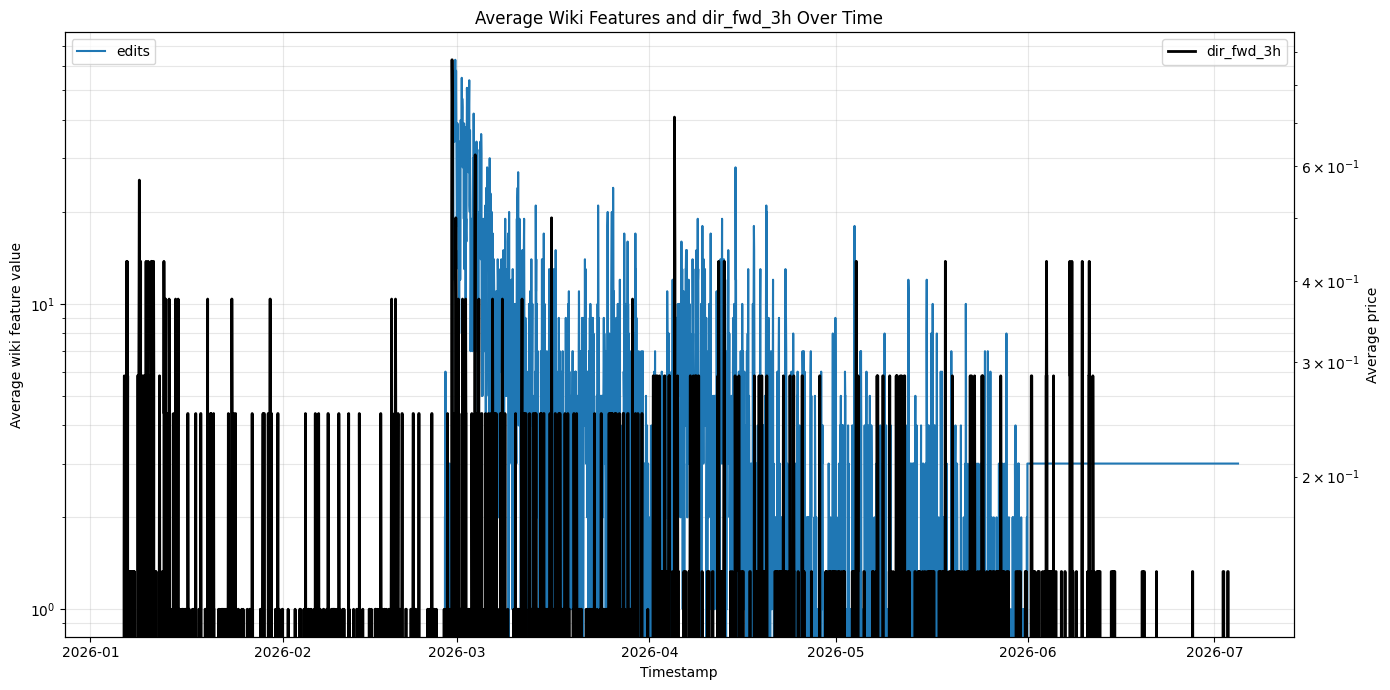

In [20]:
df = df.loc[:, ~df.columns.duplicated()].copy()
features_to_plot = [
    "edits"
]
agg = (
    df.sort_values("timestamp")
      .groupby("timestamp")[features_to_plot + [CLAS_TARGET]]
      .mean()
      .reset_index()
)

fig, ax1 = plt.subplots(figsize=(14, 7))

for feature in features_to_plot:
    ax1.plot(agg["timestamp"], agg[feature], label=feature, linewidth=1.5)

ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Average wiki feature value")
ax1.set_yscale("log")
ax1.legend(loc="upper left")
ax1.grid(alpha=0.3, which="both")

ax2 = ax1.twinx()
ax2.plot(agg["timestamp"], agg[CLAS_TARGET], label=CLAS_TARGET, color="black", linewidth=2)
ax2.set_ylabel("Average price")
ax2.set_yscale("log")
ax2.legend(loc="upper right")

plt.title(f"Average Wiki Features and {CLAS_TARGET} Over Time")
plt.tight_layout()
plt.show()

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: inva

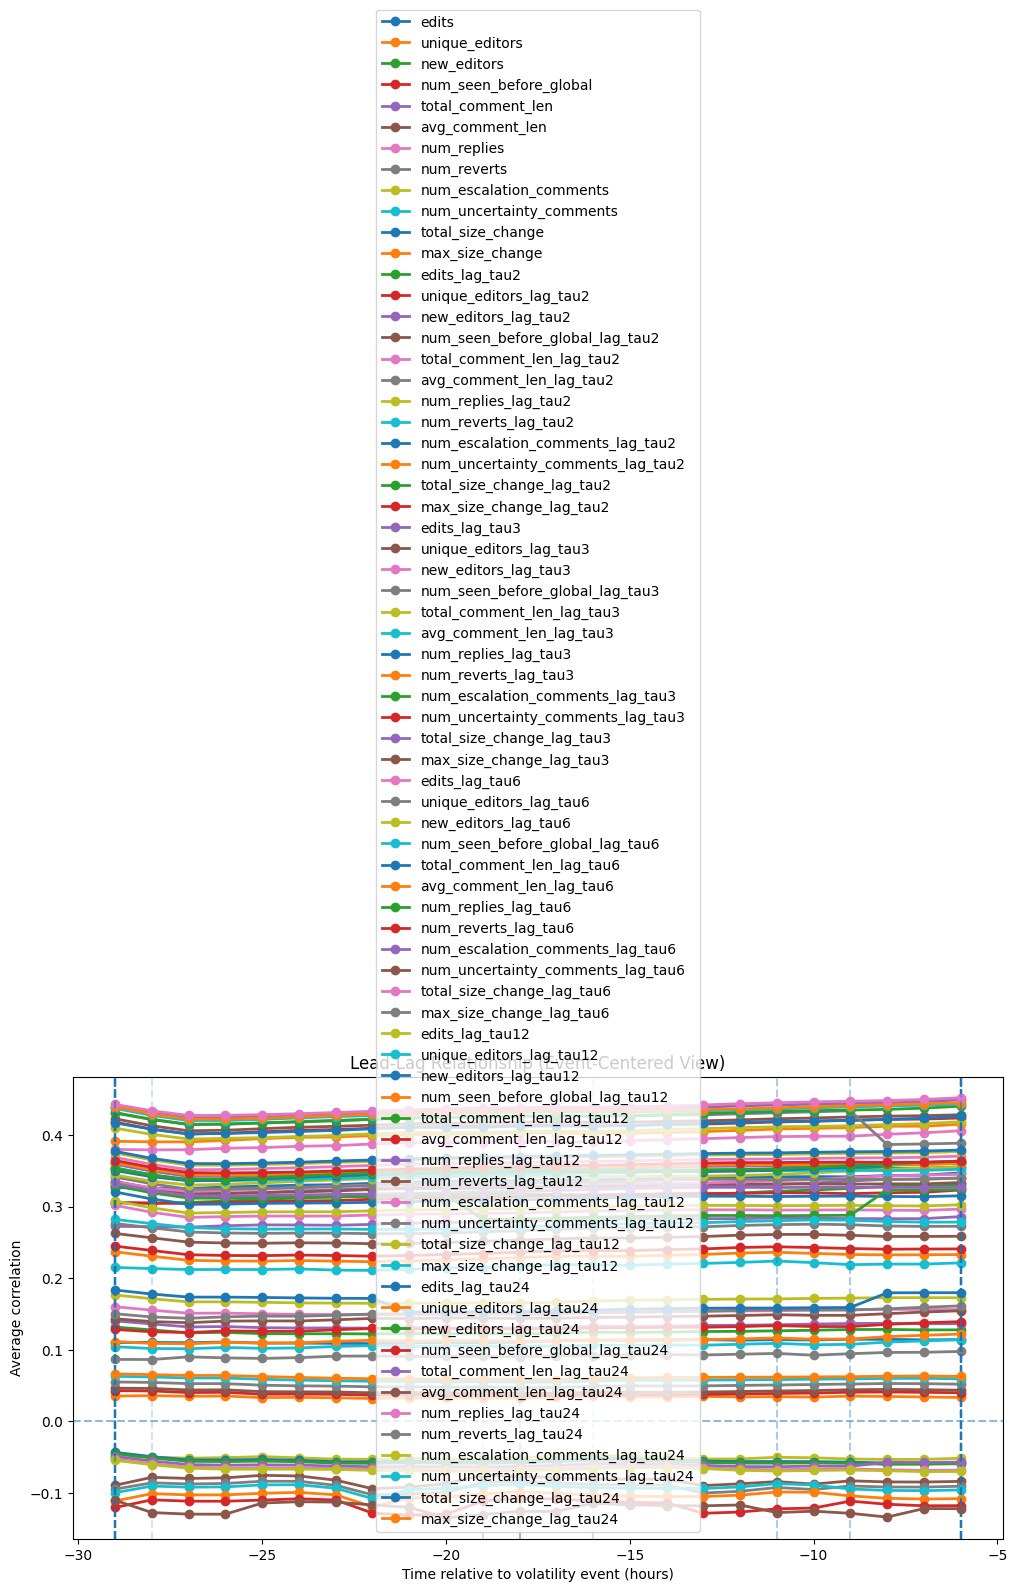

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = df.loc[:, ~df.columns.duplicated()].copy()

features_to_plot = [col for col in X_cols]

max_lag = 24
target_horizon = 6

plt.figure(figsize=(12, 6))

for feature in features_to_plot:
    market_corrs = {}

    for slug, g in df.groupby("market_slug"):
        g = g.sort_values("timestamp").copy()

        target = g["price"].shift(-target_horizon)

        corrs = []
        for lag in range(max_lag):
            x = g[feature].shift(lag)
            corrs.append(x.corr(target))

        market_corrs[slug] = corrs

    corr_df = pd.DataFrame(market_corrs)
    avg_corr = corr_df.mean(axis=1)

    # NEGATIVE time axis
    time_to_event = -(np.arange(max_lag) + target_horizon)

    plt.plot(
        time_to_event,
        avg_corr,
        marker="o",
        linewidth=2,
        label=feature
    )

    # mark strongest signal
    best_idx = np.argmax(avg_corr)
    best_time = -(best_idx + target_horizon)
    plt.axvline(best_time, linestyle="--", alpha=0.2)

plt.axhline(0, linestyle="--", alpha=0.5)

plt.xlabel("Time relative to volatility event (hours)")
plt.ylabel("Average correlation")
plt.title("Lead-Lag Relationship (Event-Centered View)")
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# remove duplicate dataframe columns from repeated cell runs
df = df.loc[:, ~df.columns.duplicated()].copy()

### Text Processing with nmf

In [23]:
# prepare text


rev_text = all_revisions.copy()
rev_text["timestamp"] = pd.to_datetime(rev_text["timestamp"], utc=True)
rev_text["hour"] = rev_text["timestamp"].dt.floor("h")

rev_text["comment"] = rev_text["comment"].fillna("").astype(str)

rev_text["diff_html"] = rev_text.get("diff_html", "").fillna("").astype(str)
rev_text["diff_clean"] = rev_text["diff_html"].apply(extract_added_text)
rev_text["diff_clean"] = rev_text["diff_clean"].apply(remove_wiki_usernames)
rev_text["is_talk"] = rev_text["page_title"].str.startswith("Talk:")

# optional: spike-hour filter
df["edit_spike"] = (
    df.groupby("market_slug")["edits"]
    .transform(lambda s: s > s.quantile(0.9))
)

df = df.drop(
    columns=[c for c in df.columns if c.startswith(("diff_nmf_", "comment_nmf_", "tfidf_nmf_", "article_", "talk_"))],
    errors="ignore"
)

spike_hours = df.loc[df["edit_spike"], "timestamp"].unique()
rev_text_model = rev_text[rev_text["hour"].isin(spike_hours)].copy()

# build separate nmf features for each category
text_cols = []
configs = [
    {"name": "article_diff", "is_talk": False, "text_col": "diff_clean", "prefix": "article_diff"},
    {"name": "article_comment", "is_talk": False, "text_col": "comment", "prefix": "article_comment"},
    {"name": "talk_diff", "is_talk": True, "text_col": "diff_clean", "prefix": "talk_diff"},
    {"name": "talk_comment", "is_talk": True, "text_col": "comment", "prefix": "talk_comment"},
]
text_cols = []
text_models = {}

for config in configs:
    subset = rev_text_model[rev_text_model["is_talk"] == config["is_talk"]].copy()

    nmf_df, vectorizer_, nmf_, terms_, cols = build_text_nmf_features_safe(
        subset,
        text_col=config["text_col"],
        prefix=config["prefix"],
        tokenizer=spacy_tokenizer,
        ngram_range=(1, 3),  # start less sparse than (1,3)
        min_df=2,            # important for small subsets
    )

    if cols:
        rev_text_model = pd.concat([rev_text_model, nmf_df], axis=1)
        text_cols.extend(cols)

        text_models[config["prefix"]] = {
            "vectorizer": vectorizer_,
            "nmf": nmf_,
            "terms": terms_,
            "cols": cols,
        }

print("Final text cols:", text_cols)
tfidf_hourly = (
    rev_text_model.groupby("hour")[text_cols]
    .mean()
    .reset_index()
    .rename(columns={"hour": "timestamp"})
)
df = df.loc[:, ~df.columns.duplicated()].copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = pd.merge_asof(
    df.sort_values("timestamp"),
    tfidf_hourly.sort_values("timestamp"),
    on="timestamp",
    direction="backward"
)

df[text_cols] = df[text_cols].fillna(0)
df = df.sort_values(["market_slug", "timestamp"]).copy()

print("Text cols:", text_cols)

Skipping article_diff: too few documents (0)
Skipping article_comment: too few documents (0)
talk_diff: docs=95, terms=36, components=10
talk_comment: docs=5348, terms=300, components=10
Final text cols: ['talk_diff_nmf_0', 'talk_diff_nmf_1', 'talk_diff_nmf_2', 'talk_diff_nmf_3', 'talk_diff_nmf_4', 'talk_diff_nmf_5', 'talk_diff_nmf_6', 'talk_diff_nmf_7', 'talk_diff_nmf_8', 'talk_diff_nmf_9', 'talk_comment_nmf_0', 'talk_comment_nmf_1', 'talk_comment_nmf_2', 'talk_comment_nmf_3', 'talk_comment_nmf_4', 'talk_comment_nmf_5', 'talk_comment_nmf_6', 'talk_comment_nmf_7', 'talk_comment_nmf_8', 'talk_comment_nmf_9']
Text cols: ['talk_diff_nmf_0', 'talk_diff_nmf_1', 'talk_diff_nmf_2', 'talk_diff_nmf_3', 'talk_diff_nmf_4', 'talk_diff_nmf_5', 'talk_diff_nmf_6', 'talk_diff_nmf_7', 'talk_diff_nmf_8', 'talk_diff_nmf_9', 'talk_comment_nmf_0', 'talk_comment_nmf_1', 'talk_comment_nmf_2', 'talk_comment_nmf_3', 'talk_comment_nmf_4', 'talk_comment_nmf_5', 'talk_comment_nmf_6', 'talk_comment_nmf_7', 'talk_c

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: inva

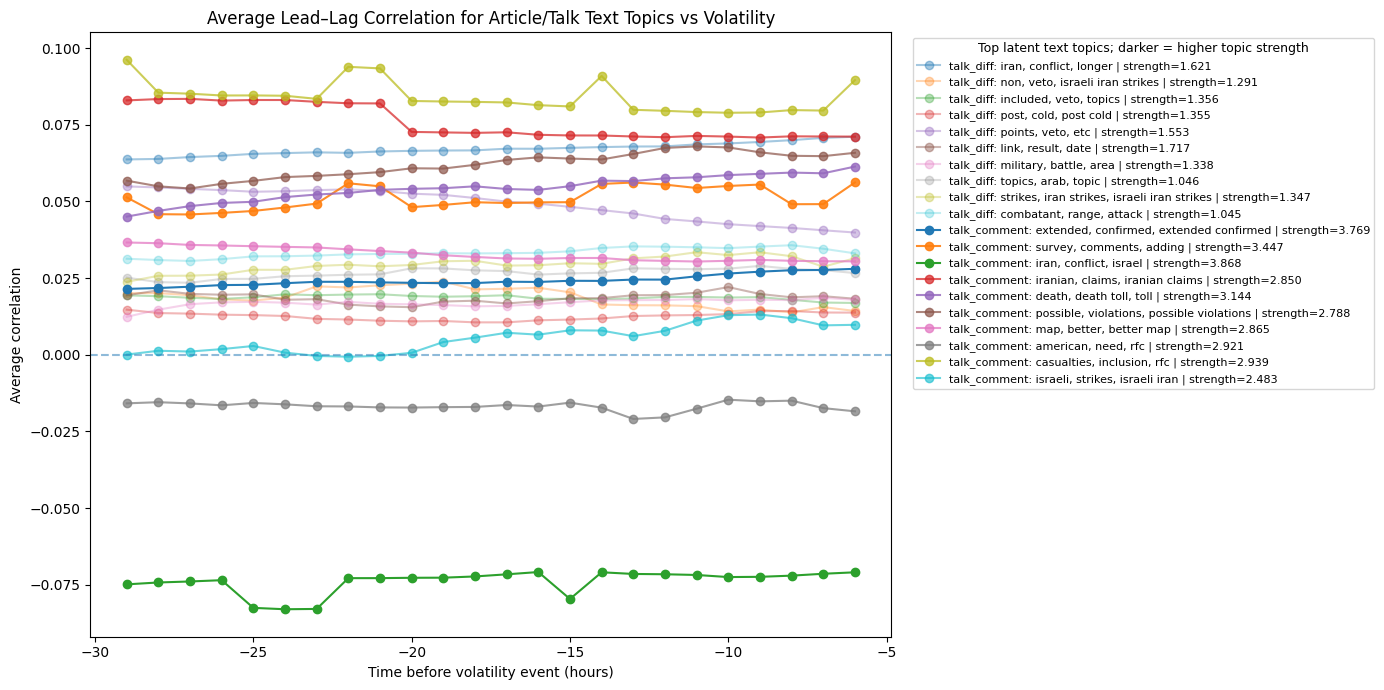

In [24]:
from utils.text.nmf import get_nmf_topic_keywords, get_nmf_topic_strengths


max_lag = 24
target_horizon = 6
time_to_event = -(np.arange(max_lag) + target_horizon)



all_strengths = np.concatenate([
    get_nmf_topic_strengths(model_obj["nmf"])
    for model_obj in text_models.values()
])

strength_min = all_strengths.min()
strength_max = all_strengths.max()

def alpha_from_strength(strength, min_alpha=0.25, max_alpha=1.0):
    """Map a topic strength to a matplotlib alpha value.

    Scales strength linearly to the [min_alpha, max_alpha] range based on
    the global strength_min and strength_max values.

    Args:
        strength (float): Topic strength to convert.
        min_alpha (float): Minimum alpha for the weakest topic.
        max_alpha (float): Maximum alpha for the strongest topic.

    Returns:
        float: Alpha value to use for plotting.
    """
    if strength_max == strength_min:
        return max_alpha
    scaled = (strength - strength_min) / (strength_max - strength_min)
    return min_alpha + scaled * (max_alpha - min_alpha)

plt.figure(figsize=(14, 7))

for model_name, model_obj in text_models.items():
    cols = model_obj["cols"]
    nmf = model_obj["nmf"]
    terms = model_obj["terms"]
    strengths = get_nmf_topic_strengths(nmf)

    for i, col in enumerate(cols):
        market_corrs = {}

        for slug, g in df.groupby("market_slug"):
            g = g.sort_values("timestamp").copy()
            target = g["price"].shift(-target_horizon)

            corrs = []
            for lag in range(max_lag):
                x = g[col].shift(lag)
                corrs.append(x.corr(target))

            market_corrs[slug] = corrs

        corr_df_temp = pd.DataFrame(market_corrs)
        avg_corr = corr_df_temp.mean(axis=1)

        label_words = ", ".join(
            get_nmf_topic_keywords(nmf, terms, i, top_n=3)["term"]
        )
        alpha = alpha_from_strength(strengths[i])

        plt.plot(
            time_to_event,
            avg_corr,
            marker="o",
            linewidth=1.5,
            alpha=alpha,
            label=f"{model_name}: {label_words} | strength={strengths[i]:.3f}"
        )

plt.axhline(0, linestyle="--", alpha=0.5)

plt.title("Average Lead–Lag Correlation for Article/Talk Text Topics vs Volatility")
plt.xlabel("Time before volatility event (hours)")
plt.ylabel("Average correlation")

plt.legend(
    title="Top latent text topics; darker = higher topic strength",
    fontsize=8,
    title_fontsize=9,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

In [25]:

# choose channel + topic
channel = "talk_comment"   # options: article_diff, article_comment, talk_diff, talk_comment
topic_idx = 2

model_obj = text_models[channel]

nmf = model_obj["nmf"]
terms = model_obj["terms"]

pos = get_nmf_topic_keywords(
    nmf,
    terms,
    topic_idx,
    top_n=15
)

print(f"Channel: {channel}")
print(f"Topic: {topic_idx}")

print("\nPositive side:")
print(pos.to_string(index=False))

Channel: talk_comment
Topic: 2

Positive side:
         term   weight
         iran 3.444613
     conflict 1.384821
       israel 0.363736
      attacks 0.296555
       crisis 0.273961
iran conflict 0.236434
     iran_war 0.217022
     protests 0.209695
        moved 0.209205
    countries 0.180845
         lead 0.180458
   flighttime 0.155918
       attack 0.155793
  iran israel 0.143795
          rfc 0.141599


### Classification

#### Log Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import numpy as np
import pandas as pd


def run_logistic_regression(feature_set, label, single_market_df, slug, clas_target):
    model_df = (
        single_market_df[["timestamp"] + feature_set + ["movement"]]
        .dropna()
        .sort_values("timestamp")
    )

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]

    y_train = train_df["movement"]
    y_test = test_df["movement"]

    # Skip degenerate train/test cases
    if y_train.nunique() < 2 or y_test.nunique() < 2:
        return None, None

    model = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            penalty="l2",
            C=1.0,
            class_weight="balanced",
            max_iter=5000,
            random_state=42,
        ),
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    metrics_row = {
        "slug": slug,
        "clas_target": clas_target,
        "model": label,
        "n_train": len(train_df),
        "n_test": len(test_df),
        "n_features": len(feature_set),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "positive_rate_train": y_train.mean(),
        "positive_rate_test": y_test.mean(),
        "positive_rate_pred": y_pred.mean(),
    }

    logreg = model.named_steps["logisticregression"]

    coef_df = pd.DataFrame({
        "slug": slug,
        "clas_target": clas_target,
        "model": label,
        "feature": feature_set,
        "coef": logreg.coef_[0],
        "abs_coef": np.abs(logreg.coef_[0]),
    })

    return metrics_row, coef_df


all_metrics = []
all_coefs = []
skipped_runs = []

for slug_obj in slugs:
    slug = slug_obj["slug"]

    for clas_target in CLAS_TARGETS:
        single_market_df = (
            df[df["market_slug"] == slug]
            .sort_values("timestamp")
            .copy()
        )

        # Directional future movement: 1 if future price change is positive, 0 otherwise
        single_market_df["movement"] = (
            single_market_df[clas_target] > 0
        ).astype(int)

        single_market_df[f"{clas_target}_lag_3"] = single_market_df[clas_target].shift(3)
        single_market_df[f"{clas_target}_lag_6"] = single_market_df[clas_target].shift(6)
        single_market_df[f"{clas_target}_lag_12"] = single_market_df[clas_target].shift(12)

        lag_features = [
            f"{clas_target}_lag_3",
            f"{clas_target}_lag_6",
            f"{clas_target}_lag_12",
        ]

        wiki_features = META_COLS + text_cols

        model_specs = [
            ("Model A: Lagged target only", lag_features),
            ("Model B: Wikipedia only", wiki_features),
            (
                "Model C: Lagged target + Wikipedia",
                list(dict.fromkeys(lag_features + wiki_features)),
            ),
        ]

        for label, features in model_specs:
            try:
                metrics_row, coef_df = run_logistic_regression(
                    feature_set=features,
                    label=label,
                    single_market_df=single_market_df,
                    slug=slug,
                    clas_target=clas_target,
                )

                if metrics_row is None:
                    skipped_runs.append({
                        "slug": slug,
                        "clas_target": clas_target,
                        "model": label,
                        "reason": "single class in train or test",
                    })
                    continue

                all_metrics.append(metrics_row)
                all_coefs.append(coef_df)

            except Exception as e:
                skipped_runs.append({
                    "slug": slug,
                    "clas_target": clas_target,
                    "model": label,
                    "reason": str(e),
                })


# ============================================================
# RESULT DATAFRAMES
# ============================================================

metrics_df = pd.DataFrame(all_metrics)
coef_df_all = pd.concat(all_coefs, ignore_index=True) if all_coefs else pd.DataFrame()
skipped_runs_df = pd.DataFrame(skipped_runs)


# ============================================================
# TABLE 1: MODEL PERFORMANCE BY TARGET
# ============================================================

performance_by_target = (
    metrics_df
    .groupby(["clas_target", "model"])
    .agg(
        n_markets=("slug", "nunique"),
        mean_roc_auc=("roc_auc", "mean"),
        std_roc_auc=("roc_auc", "std"),
        mean_bal_acc=("balanced_accuracy", "mean"),
        std_bal_acc=("balanced_accuracy", "std"),
        mean_f1=("f1", "mean"),
        mean_positive_rate_train=("positive_rate_train", "mean"),
        mean_positive_rate_test=("positive_rate_test", "mean"),
    )
    .reset_index()
    .sort_values(["clas_target", "mean_roc_auc"], ascending=[True, False])
)

display(performance_by_target)


# ============================================================
# TABLE 2: WIKIPEDIA VALUE BY TARGET
# ============================================================

roc_auc_comparison = (
    metrics_df
    .pivot_table(
        index=["slug", "clas_target"],
        columns="model",
        values="roc_auc",
        aggfunc="mean",
    )
    .reset_index()
)

roc_auc_comparison["c_minus_a_roc_auc"] = (
    roc_auc_comparison["Model C: Lagged target + Wikipedia"]
    - roc_auc_comparison["Model A: Lagged target only"]
)

wiki_value_by_target = (
    roc_auc_comparison
    .groupby("clas_target")
    .agg(
        n_markets=("slug", "nunique"),
        mean_c_minus_a=("c_minus_a_roc_auc", "mean"),
        std_c_minus_a=("c_minus_a_roc_auc", "std"),
        median_c_minus_a=("c_minus_a_roc_auc", "median"),
        share_improved=("c_minus_a_roc_auc", lambda x: (x > 0).mean()),
        best_market_gain=("c_minus_a_roc_auc", "max"),
        worst_market_loss=("c_minus_a_roc_auc", "min"),
    )
    .reset_index()
    .sort_values("mean_c_minus_a", ascending=False)
)

display(wiki_value_by_target)


# ============================================================
# TABLE 3: BIGGEST MARKET-LEVEL GAINS / LOSSES
# ============================================================

market_level_wiki_value = (
    roc_auc_comparison[
        [
            "slug",
            "clas_target",
            "Model A: Lagged target only",
            "Model C: Lagged target + Wikipedia",
            "c_minus_a_roc_auc",
        ]
    ]
    .rename(columns={
        "Model A: Lagged target only": "model_a_roc_auc",
        "Model C: Lagged target + Wikipedia": "model_c_roc_auc",
    })
    .dropna(subset=["model_a_roc_auc", "model_c_roc_auc", "c_minus_a_roc_auc"])
    .sort_values("c_minus_a_roc_auc", ascending=False)
)

top_and_bottom_markets = pd.concat(
    [
        market_level_wiki_value.head(10).assign(group="Top Wikipedia gains"),
        market_level_wiki_value.tail(10).assign(group="Worst Wikipedia losses"),
    ],
    ignore_index=True,
)

display(top_and_bottom_markets)


# ============================================================
# OPTIONAL: SKIPPED RUNS DIAGNOSTIC
# ============================================================

if len(skipped_runs_df) > 0:
    skipped_summary = (
        skipped_runs_df
        .groupby(["clas_target", "model", "reason"])
        .size()
        .reset_index(name="n_skipped")
        .sort_values("n_skipped", ascending=False)
    )

    display(skipped_summary)

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_t

,clas_target,model,n_markets,mean_roc_auc,std_roc_auc,mean_bal_acc,std_bal_acc,mean_f1,mean_positive_rate_test
0,dir_fwd_12h,Model A: Lagged target only,9,0.761536,0.102207,0.815485,0.165693,0.261879,0.051852
2,dir_fwd_12h,Model C: Lagged target + Wikipedia,9,0.749518,0.135144,0.819883,0.157416,0.264324,0.041031
1,dir_fwd_12h,Model B: Wikipedia only,9,0.445819,0.103758,0.635028,0.211689,0.067805,0.040580
5,dir_fwd_1h,Model C: Lagged target + Wikipedia,9,0.555635,0.135839,0.650101,0.254559,0.014344,0.009058
4,dir_fwd_1h,Model B: Wikipedia only,9,0.531828,0.113775,0.655889,0.259891,0.020188,0.009058
3,dir_fwd_1h,Model A: Lagged target only,9,0.476978,0.035890,0.670565,0.238100,0.029902,0.014609
8,dir_fwd_24h,Model C: Lagged target + Wikipedia,9,0.847446,0.070149,0.853307,0.093699,0.458947,0.064321
6,dir_fwd_24h,Model A: Lagged target only,9,0.838042,0.055058,0.859912,0.104984,0.466778,0.075610
7,dir_fwd_24h,Model B: Wikipedia only,9,0.481576,0.067528,0.615085,0.218469,0.031592,0.056039
9,dir_fwd_3h,Model A: Lagged target only,9,0.526819,0.027306,0.689164,0.218374,0.073720,0.026381


,clas_target,n_markets,mean_c_minus_a,std_c_minus_a,median_c_minus_a,share_improved,best_market_gain,worst_market_loss
1,dir_fwd_1h,6,0.078657,0.116973,0.035992,0.833333,0.253693,-0.053461
2,dir_fwd_24h,7,0.009405,0.022287,0.004648,0.571429,0.035979,-0.024683
0,dir_fwd_12h,6,-0.012017,0.052924,-0.009449,0.500000,0.071813,-0.089239
3,dir_fwd_3h,6,-0.013803,0.041519,-0.012022,0.166667,0.056704,-0.057588
4,dir_fwd_6h,6,-0.018686,0.082138,0.005904,0.666667,0.034497,-0.183006


model,slug,clas_target,model_a_roc_auc,model_c_roc_auc,c_minus_a_roc_auc,group
0,will-the-iranian-regime-fall-by-the-end-of-2026,dir_fwd_1h,0.502138,0.755831,0.253693,Top Wikipedia gains
1,iran-nuclear-test-before-2027,dir_fwd_1h,0.500387,0.688998,0.188611,Top Wikipedia gains
2,us-recognizes-reza-pahlavi-as-leader-of-iran-i...,dir_fwd_12h,0.759201,0.831013,0.071813,Top Wikipedia gains
3,will-the-us-invade-iran-before-2027,dir_fwd_3h,0.566432,0.623136,0.056704,Top Wikipedia gains
4,iran-nuke-before-2027,dir_fwd_1h,0.498446,0.538202,0.039756,Top Wikipedia gains
5,will-the-iranian-regime-fall-by-the-end-of-2026,dir_fwd_24h,0.828289,0.864269,0.035979,Top Wikipedia gains
6,will-the-us-invade-iran-before-2027,dir_fwd_24h,0.859678,0.895416,0.035738,Top Wikipedia gains
7,iran-nuke-before-2027,dir_fwd_6h,0.664437,0.698934,0.034497,Top Wikipedia gains
8,will-iran-withdraw-from-the-npt-before-2027,dir_fwd_1h,0.439908,0.472136,0.032228,Top Wikipedia gains
9,will-iran-withdraw-from-the-npt-before-2027,dir_fwd_6h,0.718333,0.750176,0.031843,Top Wikipedia gains


In [ ]:
y_train_shuffled = y_train.sample(frac=1, random_state=42)

model.fit(X_train_scaled, y_train_shuffled)
y_pred_prob_shuffled = model.predict_proba(X_test_scaled)[:, 1]

print("Shuffled AUC:", roc_auc_score(y_test, y_pred_prob_shuffled))

Shuffled AUC: 0.5550924198994817


In [ ]:
shuffle_aucs = []

for seed in tqdm(range(50)):
    y_perm = y_train.sample(frac=1, random_state=seed)
    m = LogisticRegression(max_iter=1000)
    m.fit(X_train_scaled, y_perm)
    pred = m.predict_proba(X_test_scaled)[:, 1]
    shuffle_aucs.append(roc_auc_score(y_test, pred))

print("Real AUC:", auc)
print("Shuffle mean:", np.mean(shuffle_aucs))
print("Shuffle max:", np.max(shuffle_aucs))

100%|██████████| 50/50 [00:25<00:00,  1.92it/s]

Real AUC: 0.5405987415580336
Shuffle mean: 0.5101788273519712
Shuffle max: 0.5849804166012251


#### nmf vizs

In [ ]:


# -------------------------------------------------
# SELECT TOP FEATURES
# -------------------------------------------------
top_n = 15

top_pos = coef_df.sort_values(
    "coef",
    ascending=False
).head(top_n)

top_neg = coef_df.sort_values(
    "coef",
    ascending=True
).head(top_n)

plot_df = pd.concat([
    top_neg,
    top_pos
]).drop_duplicates().copy()

plot_df = plot_df.sort_values("coef")

plot_df["label"] = plot_df["feature"].apply(
    lambda x: replace_nmf_with_keywords(
        x,
        text_models,
        top_n=3
    )
)

# -------------------------------------------------
# COLOR MAPPING
# -------------------------------------------------
coef_max = np.max(np.abs(plot_df["coef"]))

norm = mcolors.TwoSlopeNorm(
    vmin=-coef_max,
    vcenter=0,
    vmax=coef_max
)

cmap = cm.RdBu

colors = [
    cmap(norm(v))
    for v in plot_df["coef"]
]

# -------------------------------------------------
# PLOT
# -------------------------------------------------
fig, ax = plt.subplots(figsize=(18, 10))

y_positions = np.arange(len(plot_df))

ax.barh(
    y=y_positions,
    width=plot_df["coef"],
    color=colors,
    alpha=0.9
)

# -------------------------------------------------
# REMOVE Y TICKS
# -------------------------------------------------
ax.set_yticks([])

# -------------------------------------------------
# CENTER LINE
# -------------------------------------------------
ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.2
)

# -------------------------------------------------
# LABEL ANNOTATIONS
# -------------------------------------------------
label_offset = coef_max * 0.03

for y, coef, label in zip(
    y_positions,
    plot_df["coef"],
    plot_df["label"]
):

    # positive coefficients (blue bars)
    if coef > 0:
        ax.text(
            -label_offset,
            y,
            label,
            ha="right",
            va="center",
            fontsize=9
        )

    # negative coefficients (red bars)
    else:
        ax.text(
            label_offset,
            y,
            label,
            ha="left",
            va="center",
            fontsize=9
        )

# -------------------------------------------------
# TITLES
# -------------------------------------------------
ax.set_title(
    "Most Predictive Wikipedia-Derived Features\n"
    "Latent Topics Replaced with Top Keywords",
    fontsize=14
)

ax.set_xlabel(
    "Logistic regression coefficient",
    fontsize=12
)

# -------------------------------------------------
# CLEAN LOOK
# -------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
slug = "will-the-us-invade-iran-before-2027"
vol_col = "volatility_6h"

smooth_window = 6
vol_quantile = 0.9

# -----------------------------
# SELECT ONE MARKET
# -----------------------------
g = (
    df[df["market_slug"] == slug]
    .sort_values("timestamp")
    .copy()
)

# -----------------------------
# USE EXISTING TRAINED MODEL
# -----------------------------
plot_df = g[["timestamp", vol_col] + feature_cols].dropna().copy()

X_plot = plot_df[feature_cols]
X_plot_scaled = scaler.transform(X_plot)

plot_df["pred_prob"] = model.predict_proba(X_plot_scaled)[:, 1]
plot_df["model_score"] = model.decision_function(X_plot_scaled)

# -----------------------------
# DISPLAY VOLATILITY ONLY
# -----------------------------
plot_df["vol_smooth"] = (
    plot_df[vol_col]
    .rolling(smooth_window)
    .mean()
)

# Actual top-decile volatility for visualization only
vol_threshold = plot_df["vol_smooth"].quantile(vol_quantile)
plot_df["actual_top_decile_vol"] = plot_df["vol_smooth"] > vol_threshold

plot_df = plot_df.dropna(subset=["vol_smooth"])

# -----------------------------
# NEWS EVENTS
# -----------------------------
news_events = [
    {"time": "2026-04-02 12:00:00+00:00", "label": "Trump: hit Iran 'very hard'"},
    {"time": "2026-04-05 00:00:00+00:00", "label": "US jets reportedly shot down"},
    {"time": "2026-04-07 00:00:00+00:00", "label": "Ceasefire discussions"},
]

# -----------------------------
# PLOT
# -----------------------------
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(
    plot_df["timestamp"],
    plot_df["vol_smooth"],
    color="black",
    linewidth=2,
    label="Smoothed realized 6h volatility"
)

actual_spikes = plot_df["actual_top_decile_vol"]

ax1.scatter(
    plot_df.loc[actual_spikes, "timestamp"],
    plot_df.loc[actual_spikes, "vol_smooth"],
    color="red",
    s=40,
    label="Actual top-decile volatility"
)

ax1.set_ylabel("Smoothed realized volatility")
ax1.set_xlabel("Time (UTC)")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["timestamp"],
    plot_df["pred_prob"],
    color="orange",
    linewidth=2,
    label="Panel model predicted probability"
)

ax2.fill_between(
    plot_df["timestamp"],
    0,
    plot_df["pred_prob"],
    color="orange",
    alpha=0.25
)

# dynamic probability scale
pmax = plot_df["pred_prob"].max()
ax2.set_ylim(0, max(0.05, pmax * 1.0))
ax2.set_ylabel("Predicted probability")

# News event markers
for i, event in enumerate(news_events):
    t = pd.to_datetime(event["time"], utc=True)

    ax1.axvline(
        x=t,
        color="blue",
        linestyle="--",
        linewidth=1.3,
        alpha=0.65
    )

    y_frac = 0.96 if i % 2 == 0 else 0.86

    ax1.annotate(
        event["label"],
        xy=(t, y_frac),
        xycoords=("data", "axes fraction"),
        xytext=(8, 0),
        textcoords="offset points",
        rotation=90,
        va="top",
        ha="left",
        fontsize=8,
        color="blue",
        bbox=dict(
            boxstyle="round,pad=0.25",
            fc="white",
            ec="blue",
            alpha=0.75,
            linewidth=0.7
        ),
        clip_on=True,
        zorder=10
    )

plt.title(
    f"Panel Model Predictions vs Realized Volatility\n"
    f"Market: {slug}"
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left"
)

plt.xlim(plot_df["timestamp"].min(), plot_df["timestamp"].max())
plt.tight_layout()
plt.show()

### Regression

#### Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

single_market_df = df[df["market_slug"] == MARKET].sort_values("timestamp").copy()

# Lagged CLAS_TARGET features
single_market_df[f"{REG_TARGET}_lag_1"] = single_market_df[REG_TARGET].shift(1)
single_market_df[f"{REG_TARGET}_lag_3"] = single_market_df[REG_TARGET].shift(3)
single_market_df[f"{REG_TARGET}_lag_6"] = single_market_df[REG_TARGET].shift(6)
single_market_df[f"{REG_TARGET}_lag_12"] = single_market_df[REG_TARGET].shift(12)

lag_features = [
    f"{REG_TARGET}_lag_1",
    f"{REG_TARGET}_lag_3",
    f"{REG_TARGET}_lag_6",
    f"{REG_TARGET}_lag_12",
]

wiki_features = feature_cols.copy()


def run_linear_regression(feature_set, label):
    model_df = (
        single_market_df[["timestamp"] + feature_set + [REG_TARGET]]
        .dropna()
        .sort_values("timestamp")
    )

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[REG_TARGET]
    y_test = test_df[REG_TARGET]

    model = make_pipeline(
        StandardScaler(),
        LinearRegression(),
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    linreg = model.named_steps["linearregression"]

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("Intercept:", linreg.intercept_)
    print("Nonzero coefficients:", np.sum(linreg.coef_ != 0))

    coef_df = pd.DataFrame(
        {
            "feature": feature_set,
            "coef": linreg.coef_,
        }
    ).sort_values("coef", ascending=False)

    print("\nTop positive coefficients:")
    print(coef_df.head(10))

    print("\nTop negative coefficients:")
    print(coef_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "coef_df": coef_df,
    }


# Model A: lagged REG_TARGET only
result_lags = run_linear_regression(lag_features, "Model A: Lagged REG_TARGET only")

# Model B: Wikipedia features only
result_wiki = run_linear_regression(wiki_features, "Model B: Wikipedia features only")

# Model C: lagged REG_TARGET + Wikipedia features
result_combined = run_linear_regression(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged REG_TARGET + Wikipedia features",
)



Model A: Lagged REG_TARGET only
n_train: 3015
n_test: 1293
n_features: 4
R2: 0.985532477983869
MAE: 0.002854035565821841
Intercept: 0.28121890547263684
Nonzero coefficients: 4

Top positive coefficients:
        feature      coef
0   price_lag_1  0.155328
3  price_lag_12  0.002446
2   price_lag_6  0.001553
1   price_lag_3 -0.000584

Top negative coefficients:
        feature      coef
0   price_lag_1  0.155328
3  price_lag_12  0.002446
2   price_lag_6  0.001553
1   price_lag_3 -0.000584

Model B: Wikipedia features only
n_train: 2111
n_test: 905
n_features: 92
R2: -107.56151746802557
MAE: 0.2588108441440193
Intercept: 0.3628919943154475
Nonzero coefficients: 92

Top positive coefficients:
                             feature        coef
24                    edits_lag_tau3  985.105322
48                   edits_lag_tau12  971.260185
39   num_seen_before_global_lag_tau6  800.706080
15   num_seen_before_global_lag_tau2  528.483344
63  num_seen_before_global_lag_tau24  338.507453
38     

#### ElasticNetCV

In [ ]:
[i for i in df.columns if "dir" in i]

['dir_fwd_1h', 'dir_fwd_3h', 'dir_fwd_6h', 'dir_fwd_12h', 'dir_fwd_24h']

In [ ]:
from sklearn.linear_model import ElasticNetCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

single_market_df = df[df["market_slug"] == MARKET].sort_values("timestamp").copy()

# Lagged CLAS_TARGET features
single_market_df[f"{REG_TARGET}_lag_1"] = single_market_df[REG_TARGET].shift(1)
single_market_df[f"{REG_TARGET}_lag_3"] = single_market_df[REG_TARGET].shift(3)
single_market_df[f"{REG_TARGET}_lag_6"] = single_market_df[REG_TARGET].shift(6)
single_market_df[f"{REG_TARGET}_lag_12"] = single_market_df[REG_TARGET].shift(12)

lag_features = [
    f"{REG_TARGET}_lag_1",
    f"{REG_TARGET}_lag_3",
    f"{REG_TARGET}_lag_6",
    f"{REG_TARGET}_lag_12",
]

wiki_features = feature_cols.copy()


def run_elasticnet(feature_set, label):
    model_df = (
        single_market_df[["timestamp"] + feature_set + [REG_TARGET]]
        .dropna()
        .sort_values("timestamp")
    )

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[REG_TARGET]
    y_test = test_df[REG_TARGET]

    tscv = TimeSeriesSplit(n_splits=5)

    model = make_pipeline(
        StandardScaler(),
        ElasticNetCV(
            l1_ratio=[0.001, 0.01, 0.05, 0.1, 0.5, 0.9],
            alphas=np.logspace(-3, 1, 80),
            cv=tscv,
            max_iter=100000,
            tol=1e-4,
            selection="random",
            random_state=42,
        ),
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    elasticnet = model.named_steps["elasticnetcv"]

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("Best alpha:", elasticnet.alpha_)
    print("Best l1_ratio:", elasticnet.l1_ratio_)
    print("Nonzero coefficients:", np.sum(elasticnet.coef_ != 0))

    coef_df = pd.DataFrame(
        {
            "feature": feature_set,
            "coef": elasticnet.coef_,
        }
    ).sort_values("coef", ascending=False)

    print("\nTop positive coefficients:")
    print(coef_df.head(10))

    print("\nTop negative coefficients:")
    print(coef_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "coef_df": coef_df,
    }


# Model A: lagged CLAS_TARGET only
result_lags = run_elasticnet(lag_features, "Model A: Lagged CLAS_TARGET only")

# Model B: Wikipedia features only
result_wiki = run_elasticnet(wiki_features, "Model B: Wikipedia features only")

# Model C: lagged CLAS_TARGET + Wikipedia features
result_combined = run_elasticnet(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged CLAS_TARGET + Wikipedia features",
)


Model A: Lagged CLAS_TARGET only
n_train: 3015
n_test: 1293
n_features: 4
R2: 0.9856788634970848
MAE: 0.002996133837408555
Best alpha: 0.001
Best l1_ratio: 0.001
Nonzero coefficients: 4

Top positive coefficients:
        feature      coef
0   price_lag_1  0.140680
1   price_lag_3  0.012692
3  price_lag_12  0.002997
2   price_lag_6  0.002311

Top negative coefficients:
        feature      coef
0   price_lag_1  0.140680
1   price_lag_3  0.012692
3  price_lag_12  0.002997
2   price_lag_6  0.002311

Model B: Wikipedia features only
n_train: 2111
n_test: 905
n_features: 92
R2: -68.13584979382544
MAE: 0.20829530923261735
Best alpha: 0.18988078244652631
Best l1_ratio: 0.5
Nonzero coefficients: 0

Top positive coefficients:
                             feature  coef
0                              edits  -0.0
58       total_size_change_lag_tau12  -0.0
67             num_reverts_lag_tau24  -0.0
66             num_replies_lag_tau24  -0.0
65         avg_comment_len_lag_tau24   0.0
64       tota

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd


single_market_df = (
    df[df["market_slug"] == MARKET]
    .sort_values("timestamp")
    .copy()
)

# Lagged REG_TARGET features
single_market_df[f"{REG_TARGET}_lag_1"] = single_market_df[REG_TARGET].shift(1)
single_market_df[f"{REG_TARGET}_lag_3"] = single_market_df[REG_TARGET].shift(3)
single_market_df[f"{REG_TARGET}_lag_6"] = single_market_df[REG_TARGET].shift(6)
single_market_df[f"{REG_TARGET}_lag_12"] = single_market_df[REG_TARGET].shift(12)

lag_features = [
    f"{REG_TARGET}_lag_1",
    f"{REG_TARGET}_lag_3",
    f"{REG_TARGET}_lag_6",
    f"{REG_TARGET}_lag_12",
]

wiki_features = feature_cols.copy()

def run_random_forest(feature_set, label):
    model_df = single_market_df[
        ["timestamp"] + feature_set + [REG_TARGET]
    ].dropna().sort_values("timestamp")

    split = int(len(model_df) * 0.7)

    train_df = model_df.iloc[:split].copy()
    test_df = model_df.iloc[split:].copy()

    X_train = train_df[feature_set]
    X_test = test_df[feature_set]
    y_train = train_df[REG_TARGET]
    y_test = test_df[REG_TARGET]

    model = RandomForestRegressor(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=10,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n" + "=" * 60)
    print(label)
    print("=" * 60)
    print("n_train:", len(train_df))
    print("n_test:", len(test_df))
    print("n_features:", len(feature_set))
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))

    importance_df = pd.DataFrame({
        "feature": feature_set,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False)

    print("\nTop feature importances:")
    print(importance_df.head(10))

    print("\nLeast important features:")
    print(importance_df.tail(10))

    return {
        "label": label,
        "model": model,
        "test_df": test_df,
        "y_test": y_test,
        "y_pred": y_pred,
        "importance_df": importance_df,
    }


# Model A: lagged REG_TARGET only
result_lags = run_random_forest(
    lag_features,
    "Model A: Lagged REG_TARGET only"
)

# Model B: Wikipedia features only
result_wiki = run_random_forest(
    wiki_features,
    "Model B: Wikipedia features only"
)

# Model C: lagged REG_TARGET + Wikipedia features
result_combined = run_random_forest(
    list(dict.fromkeys(lag_features + wiki_features)),
    "Model C: Lagged REG_TARGET + Wikipedia features"
)



Model A: Lagged REG_TARGET only
n_train: 3008
n_test: 1290
n_features: 4
R2: 0.8259023894204682
MAE: 0.0012682669629652792

Top feature importances:
                       feature  importance
0   future_volatility_6h_lag_1    0.683368
1   future_volatility_6h_lag_3    0.239811
2   future_volatility_6h_lag_6    0.065534
3  future_volatility_6h_lag_12    0.011286

Least important features:
                       feature  importance
0   future_volatility_6h_lag_1    0.683368
1   future_volatility_6h_lag_3    0.239811
2   future_volatility_6h_lag_6    0.065534
3  future_volatility_6h_lag_12    0.011286

Model B: Wikipedia features only
n_train: 2107
n_test: 904
n_features: 92
R2: -2.206558989861561
MAE: 0.00818926977813653

Top feature importances:
               feature  importance
82  talk_comment_nmf_0    0.084483
88  talk_comment_nmf_6    0.064831
91  talk_comment_nmf_9    0.045888
83  talk_comment_nmf_1    0.041467
90  talk_comment_nmf_8    0.034750
86  talk_comment_nmf_4    0.032480

#### ARIMA

In [ ]:
import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# DATA
# -----------------------------
y = (
    g[["timestamp", REG_TARGET]]
    .dropna()
    .sort_values("timestamp")
    .set_index("timestamp")[REG_TARGET]
)

y = y.asfreq("1h").ffill()
y = np.log(y + 1e-6)

split = int(len(y) * 0.7)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

# -----------------------------
# STATIC ARIMA
# -----------------------------
res = ARIMA(y_train, order=(1, 0, 1)).fit()

static_forecast = res.forecast(steps=len(y_test))
static_forecast.index = y_test.index

# -----------------------------
# WALK-FORWARD ARIMA, FAST VERSION
# -----------------------------
res_walk = ARIMA(y_train, order=(1, 0, 1)).fit()

walk_preds = []

for t, obs in y_test.items():
    pred = res_walk.forecast(steps=1).iloc[0]
    walk_preds.append(pred)

    # update model with true observed value, but do not refit parameters
    res_walk = res_walk.append([obs], refit=False)

walk_forecast = pd.Series(walk_preds, index=y_test.index)

# -----------------------------
# NAIVE LAG-1
# -----------------------------
naive = y.shift(1).loc[y_test.index]

# -----------------------------
# METRICS
# -----------------------------
def print_metrics(name, actual, pred):
    print(f"{name} MAE:", mean_absolute_error(actual, pred))
    print(f"{name} RMSE:", np.sqrt(mean_squared_error(actual, pred)))
    print(f"{name} R2:", r2_score(actual, pred))
    print()

print_metrics("Static ARIMA", y_test, static_forecast)
print_metrics("Walk ARIMA", y_test, walk_forecast)
print_metrics("Naive", y_test, naive)

/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/tallywiesenberg/Repositories/UMBC/MATH-490/thinking-bee/venv/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Static ARIMA MAE: 0.37819877047030853
Static ARIMA RMSE: 0.41622275206687476
Static ARIMA R2: -0.9932553733698273

Walk ARIMA MAE: 0.013824677956827876
Walk ARIMA RMSE: 0.034649099307654335
Walk ARIMA R2: 0.9861867710514645

Naive MAE: 0.012755043133526671
Naive RMSE: 0.034887349690057384
Naive R2: 0.9859961558967653



#### SARIMAX

Static SARIMAX MAE: 1.1181909082876729
Static SARIMAX RMSE: 1.131865722287014
Static SARIMAX R2: -49.87825033553866

Walk SARIMAX MAE: 0.1914184292295674
Walk SARIMAX RMSE: 0.1972124801265157
Walk SARIMAX R2: -0.5445826128022253

Naive MAE: 0.010865436744095028
Naive RMSE: 0.032945258813058306
Naive R2: 0.9568949454066766



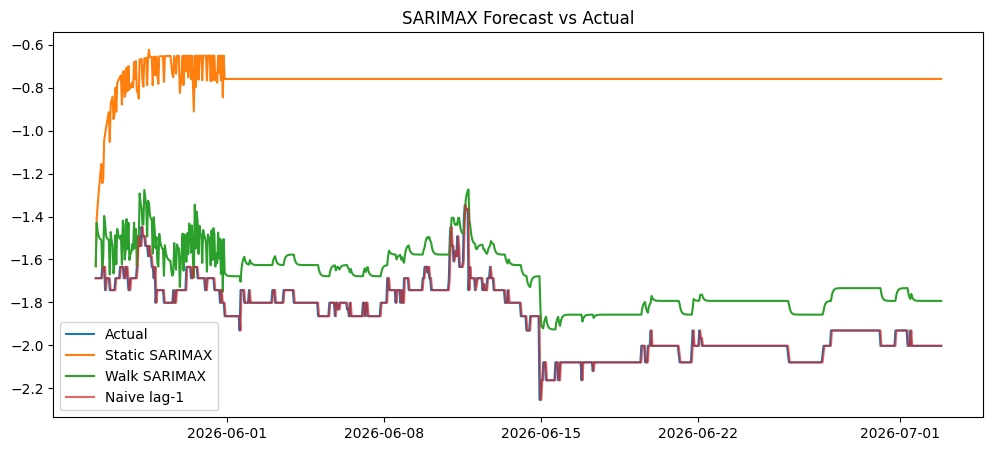

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -------------------------------------------------
# CONFIG
# -------------------------------------------------
selected_features = meta_cols

# -------------------------------------------------
# BUILD DATA
# -------------------------------------------------
model_df = (
    g[["timestamp", REG_TARGET] + selected_features]
    .dropna()
    .sort_values("timestamp")
    .set_index("timestamp")
)

model_df = model_df.asfreq("1h").ffill()

y = np.log(model_df[REG_TARGET] + 1e-6)
X = model_df[selected_features]

split = int(len(model_df) * 0.7)

y_train = y.iloc[:split]
y_test = y.iloc[split:]

X_train = X.iloc[:split]
X_test = X.iloc[split:]

# -------------------------------------------------
# STATIC SARIMAX
# fit once, forecast whole test set
# -------------------------------------------------
res_static = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

static_forecast = res_static.forecast(
    steps=len(y_test),
    exog=X_test,
)

static_forecast.index = y_test.index

# -------------------------------------------------
# WALK-FORWARD SARIMAX
# fit once, update state without refitting
# -------------------------------------------------
res_walk = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 0, 1),
    trend="c",
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

walk_preds = []

for i, (t, obs) in enumerate(y_test.items()):
    x_next = X_test.iloc[[i]]

    pred = res_walk.forecast(
        steps=1,
        exog=x_next,
    ).iloc[0]

    walk_preds.append(pred)

    new_y = pd.Series(
        [obs],
        index=pd.DatetimeIndex([t], freq=y.index.freq),
        name=y_train.name,
    )

    res_walk = res_walk.append(
        endog=new_y,
        exog=x_next,
        refit=False,
    )

walk_forecast = pd.Series(walk_preds, index=y_test.index)

# -------------------------------------------------
# NAIVE LAG-1 BASELINE
# -------------------------------------------------
naive = y.shift(1).loc[y_test.index]

# -------------------------------------------------
# METRICS
# -------------------------------------------------
def print_metrics(name, actual, pred):
    print(f"{name} MAE:", mean_absolute_error(actual, pred))
    print(f"{name} RMSE:", np.sqrt(mean_squared_error(actual, pred)))
    print(f"{name} R2:", r2_score(actual, pred))
    print()

print_metrics("Static SARIMAX", y_test, static_forecast)
print_metrics("Walk SARIMAX", y_test, walk_forecast)
print_metrics("Naive", y_test, naive)

# -------------------------------------------------
# PLOT
# -------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(static_forecast.index, static_forecast, label="Static SARIMAX")
plt.plot(walk_forecast.index, walk_forecast, label="Walk SARIMAX")
plt.plot(naive.index, naive, label="Naive lag-1", alpha=0.7)
plt.legend()
plt.title("SARIMAX Forecast vs Actual")
plt.show()